In [ ]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
# Colab users: mount Drive. If local, skip or set local paths.
from google.colab import drive
drive.mount('/content/drive')

# Update these paths if using local
ISIC_IMG_DIR = "/content/drive/MyDrive/ISIC_3B/images"
ISIC_MSK_DIR = "/content/drive/MyDrive/ISIC_3B/masks"
OUT_MASK_DIR = "/content/drive/MyDrive/ISIC_3B/predicted_masks"   # predicted (optional)
OUT_ROI_DIR   = "/content/drive/MyDrive/ISIC_3B/roi_fixed"
OUT_FEATURES  = "/content/drive/MyDrive/ISIC_3B/ABCD_features.csv"
CKPT_DIR      = "/content/drive/MyDrive/ISIC_3B/checkpoints"
IMG_DIR = "/content/drive/MyDrive/ISIC_3B/images"
MASK_DIR = "/content/drive/MyDrive/ISIC_3B/predicted_masks"
ROI_DIR  = "/content/drive/MyDrive/ISIC_3B/roi_fixed"
os.makedirs(OUT_MASK_DIR, exist_ok=True)
os.makedirs(OUT_ROI_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)


ValueError: Mountpoint must not already contain files

In [ ]:
!ls -a /content/drive

.  ..  MyDrive


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


ValueError: Mountpoint must not already contain files

In [ ]:
# Cell 0 — mount drive
from google.colab import drive
drive.mount('/content/drive')


ValueError: Mountpoint must not already contain files

In [ ]:
import os
img_dir = "/content/drive/MyDrive/ISIC_3B/images"
mask_dir = "/content/drive/MyDrive/ISIC_3B/masks"

print("images exist:", os.path.exists(img_dir))
print("masks exist: ", os.path.exists(mask_dir))
if os.path.exists(img_dir):
    imgs = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print("image count:", len(imgs), "example:", imgs[:5])
else:
    print("-> Upload images to", img_dir)

if os.path.exists(mask_dir):
    msks = [f for f in os.listdir(mask_dir) if f.lower().endswith(('.png'))]
    print("mask count:", len(msks), "example:", msks[:5])
else:
    print("-> Upload masks to", mask_dir)


images exist: True
masks exist:  True
image count: 900 example: ['ISIC_0008879.jpg', 'ISIC_0000467.jpg', 'ISIC_0000376.jpg', 'ISIC_0000275.jpg', 'ISIC_0001102.jpg']
mask count: 900 example: ['ISIC_0000108_Segmentation.png', 'ISIC_0000458_Segmentation.png', 'ISIC_0001213_Segmentation.png', 'ISIC_0000179_Segmentation.png', 'ISIC_0004168_Segmentation.png']


In [ ]:
!pip install -q albumentations==1.3.0 segmentation-models-pytorch==0.3.3 timm==0.9.2 pytorch-lightning==1.8.6 torchmetrics
!pip install -q matplotlib opencv-python pillow scikit-learn
!pip install -q grad-cam==1.4.6


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.3/800.3 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 64.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


In [ ]:
import segmentation_models_pytorch as smp
import albumentations as A
import sklearn
from pytorch_grad_cam import GradCAM

print("Sab perfect chal raha hai bhai 🔥")


Sab perfect chal raha hai bhai 🔥


In [ ]:
# Set your ISIC dataset paths
ISIC_IMG_DIR = "/content/drive/MyDrive/ISIC_3B/images"
ISIC_MSK_DIR = "/content/drive/MyDrive/ISIC_3B/masks"

print("Images exist:", ISIC_IMG_DIR, "->", len([f for f in os.listdir(ISIC_IMG_DIR) if f.endswith('.jpg')]))
print("Masks exist:", ISIC_MSK_DIR, "->", len([f for f in os.listdir(ISIC_MSK_DIR) if f.endswith('.png')]))


Images exist: /content/drive/MyDrive/ISIC_3B/images -> 900
Masks exist: /content/drive/MyDrive/ISIC_3B/masks -> 900


In [ ]:
MIDAS_CSV = "/content/drive/MyDrive/MRA-MIDAS/triplet_with_labels.csv"
MIDAS_IMG_DIR = "/content/drive/MyDrive/MRA-MIDAS/images"
OUT_MASK_DIR = "/content/drive/MyDrive/MRA-MIDAS/dermo_masks"
OUT_OVERLAY_DIR = "/content/drive/MyDrive/MRA-MIDAS/dermo_overlays"
OUT_ROI_DIR = "/content/drive/MyDrive/MRA-MIDAS/dermo_roi"

os.makedirs(OUT_MASK_DIR, exist_ok=True)
os.makedirs(OUT_OVERLAY_DIR, exist_ok=True)
os.makedirs(OUT_ROI_DIR, exist_ok=True)


In [ ]:
# imports
import os, math, time, random
import numpy as np, pandas as pd, cv2
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from efficientnet_pytorch import EfficientNet

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cpu


In [ ]:
class ISICSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, file_list=None, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        if file_list is None:
            self.files = sorted([f for f in os.listdir(image_dir) if f.endswith(".jpg")])
        else:
            self.files = file_list

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        img_path = os.path.join(self.image_dir, fname)
        mask_path = os.path.join(self.mask_dir, fname.replace(".jpg", "_segmentation.png"))

        # load
        img = cv2.imread(img_path)[:,:,::-1]
        mask = cv2.imread(mask_path, 0)
        mask = (mask > 0).astype("float32")

        # apply albumentations
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"].unsqueeze(0).float()   # ⭐ IMPORTANT ⭐
        else:
            img = img.astype("float32")/255.
            img = torch.from_numpy(img.transpose(2,0,1)).float()
            mask = torch.from_numpy(mask).unsqueeze(0).float()

        return img, mask


In [ ]:
val_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])

In [ ]:
all_imgs = sorted([os.path.basename(p) for p in glob(os.path.join(ISIC_IMG_DIR,"*.jpg"))])
print("Total ISIC images found:", len(all_imgs))

random.seed(42)
random.shuffle(all_imgs)
n = len(all_imgs)
ntrain = int(0.9 * n)
train_files = all_imgs[:ntrain]
val_files   = all_imgs[ntrain:]

train_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])
train_ds = ISICSegDataset(ISIC_IMG_DIR, ISIC_MSK_DIR, file_list=train_files, transform=train_tf)
val_ds   = ISICSegDataset(ISIC_IMG_DIR, ISIC_MSK_DIR, file_list=val_files, transform=val_tf)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print("Train len:", len(train_ds), "Val len:", len(val_ds))


Total ISIC images found: 900
Train len: 810 Val len: 90


In [ ]:
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                 in_channels=3, classes=1, activation=None).to(device)

bce = nn.BCEWithLogitsLoss()
def dice_loss(pred, target, smooth=1.0):
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)
    target = target.view(-1)
    inter = (pred * target).sum()
    return 1 - ((2.*inter + smooth)/(pred.sum() + target.sum() + smooth))

def combined_loss(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=3,
    factor=0.5
)


In [ ]:
print("LR:", optimizer.param_groups[0]['lr'])


LR: 0.0001


In [ ]:
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 102
Val batches: 12


In [ ]:
def evaluate(model, loader):
    model.eval()
    dices = []
    tot_loss = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device); masks = masks.to(device)
            preds = model(imgs)
            loss = combined_loss(preds, masks)
            tot_loss += loss.item()
            pr = (torch.sigmoid(preds) > 0.5).float()
            # compute per-batch dice
            inter = (pr * masks).sum(dim=[1,2,3])
            union = pr.sum(dim=[1,2,3]) + masks.sum(dim=[1,2,3])
            batch_dice = ((2*inter + 1) / (union + 1)).mean().item()
            dices.append(batch_dice)
    return tot_loss / len(loader), np.mean(dices)

best_val = 1e9
EPOCHS = 7  # you can increase to 20 if time allows

for epoch in range(EPOCHS):
    model.train()
    t0 = time.time()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs = imgs.to(device); masks = masks.to(device)
        preds = model(imgs)
        loss = combined_loss(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    val_loss, val_dice = evaluate(model, val_loader)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_dice={val_dice:.4f} | time={(time.time()-t0):.1f}s")
    # save best
    ckpt = os.path.join(CKPT_DIR, f"unet_epoch{epoch+1}.pth")
    torch.save(model.state_dict(), ckpt)
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), os.path.join(CKPT_DIR, "unet_best.pth"))
        print("Saved best model.")


Epoch 1/7 | train_loss=0.4846 | val_loss=0.4030 | val_dice=0.9015 | time=66.6s
Saved best model.
Epoch 2/7 | train_loss=0.3629 | val_loss=0.3417 | val_dice=0.9111 | time=50.8s
Saved best model.
Epoch 3/7 | train_loss=0.2890 | val_loss=0.2936 | val_dice=0.9101 | time=53.3s
Saved best model.
Epoch 4/7 | train_loss=0.2281 | val_loss=0.2839 | val_dice=0.9116 | time=51.9s
Saved best model.
Epoch 5/7 | train_loss=0.1992 | val_loss=0.2494 | val_dice=0.9171 | time=52.8s
Saved best model.
Epoch 6/7 | train_loss=0.1898 | val_loss=0.2603 | val_dice=0.9098 | time=53.1s
Epoch 7/7 | train_loss=0.1540 | val_loss=0.2532 | val_dice=0.9114 | time=50.7s


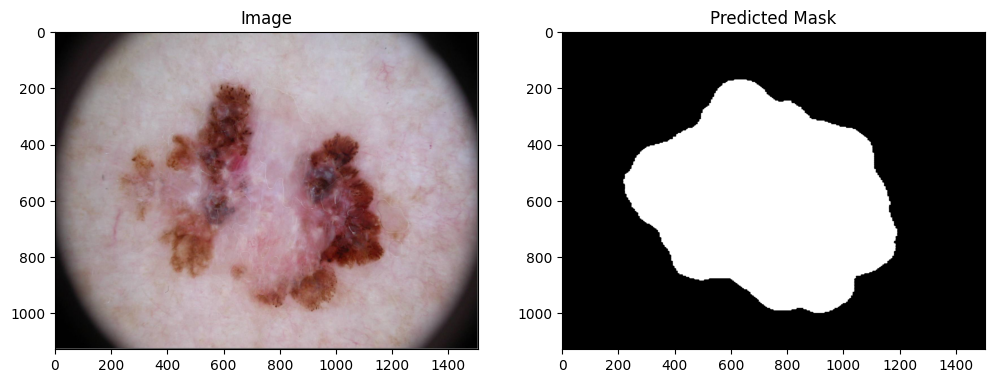

In [ ]:
import matplotlib.pyplot as plt

test_img = "/content/drive/MyDrive/ISIC_3B/images/ISIC_0000031.jpg"

img = cv2.imread(test_img)[:,:,::-1]
h,w = img.shape[:2]

aug = val_tf(image=img)
inp = aug["image"].unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    pred = torch.sigmoid(model(inp))[0,0].cpu().numpy()

mask = (pred > 0.5).astype("uint8")
mask = cv2.resize(mask, (w,h))

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(img); plt.title("Image")
plt.subplot(1,2,2); plt.imshow(mask, cmap='gray'); plt.title("Predicted Mask")
plt.show()


In [ ]:
# Load best U-Net checkpoint
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
).to(device)

best_ckpt = "/content/drive/MyDrive/ISIC_3B/checkpoints/unet_best.pth"
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()

print("Loaded best U-Net model!")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ISIC_3B/checkpoints/unet_best.pth'

In [ ]:
import pandas as pd
import ast

df = pd.read_csv(MIDAS_CSV)

dermo_files = []

for i, row in df.iterrows():
    dermo = row["dermo"]
    if isinstance(dermo, float):
        continue
    dermo_files.append(dermo)

dermo_files = list(set(dermo_files))
print("Total dermoscopic files detected:", len(dermo_files))
print(dermo_files[:10])


Total dermoscopic files detected: 1049
['s-prd-473132718.jpg', 's-prd-478009162.jpg', 's-prd-667262631.jpg', 's-prd-411891363.jpg', 's-prd-818019450.jpg', 's-prd-625916231.jpg', 's-prd-421727395.jpg', 's-prd-501923347.jpg', 's-prd-515512175.jpg', 's-prd-743590784.jpg']


In [ ]:
import cv2
import numpy as np
from tqdm import tqdm
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Load trained U-Net
best_ckpt = "/content/drive/MyDrive/ISIC_3B/checkpoints/unet_best.pth"
model = smp.Unet("resnet34", encoder_weights="imagenet", classes=1, activation=None).to(device)
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()

# transforms
infer_tf = A.Compose([
    A.Resize(256,256),
    A.Normalize(),
    ToTensorV2()
])

def keep_largest_component(mask):
    cnts,_ = cv2.findContours((mask>0).astype('uint8'), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return mask
    c = max(cnts, key=cv2.contourArea)
    out = np.zeros_like(mask)
    cv2.drawContours(out, [c], -1, 255, -1)
    return out

for fname in tqdm(dermo_files):
    in_path = os.path.join(MIDAS_IMG_DIR, fname)
    if not os.path.exists(in_path):
        continue

    img = cv2.imread(in_path)
    if img is None:
        continue
    img_rgb = img[:,:,::-1]

    h,w = img_rgb.shape[:2]
    aug = infer_tf(image=img_rgb)
    tensor = aug["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(tensor)[0,0].cpu().numpy()

    mask = (1/(1+np.exp(-pred)) > 0.5).astype('uint8')
    mask_big = cv2.resize(mask, (w,h), interpolation=cv2.INTER_NEAREST) * 255

    # save mask
    cv2.imwrite(os.path.join(OUT_MASK_DIR, fname.replace(".jpg",".png")), mask_big)

    # overlay
    overlay = img_rgb.copy()
    overlay[mask_big>0] = (0.5 * overlay[mask_big>0] + 0.5 * np.array([255,0,0])).astype(np.uint8)
    cv2.imwrite(os.path.join(OUT_OVERLAY_DIR, fname), overlay[:,:,::-1])

    # ROI extraction
    m = keep_largest_component(mask_big)
    cnts,_ = cv2.findContours((m>0).astype('uint8'), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        x,y,w2,h2 = cv2.boundingRect(cnts[0])
        roi = img_rgb[y:y+h2, x:x+w2]
        roi = cv2.resize(roi, (224,224))
        cv2.imwrite(os.path.join(OUT_ROI_DIR, fname), roi[:,:,::-1])


100%|██████████| 1049/1049 [25:10<00:00,  1.44s/it]


In [ ]:
import os
import cv2
import torch
import numpy as np
import albumentations as A

os.makedirs(OUT_MASK_DIR, exist_ok=True)

transform = A.Compose([
    A.Resize(256,256),
    A.Normalize(),
])

model.eval()

all_imgs = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".jpg")])

print("Total images:", len(all_imgs))

for f in all_imgs:
    path = os.path.join(IMG_DIR, f)
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    aug = transform(image=img_rgb)
    t = torch.tensor(aug["image"].transpose(2,0,1)).float().unsqueeze(0).to(device)

    with torch.no_grad():
        p = torch.sigmoid(model(t))[0,0].cpu().numpy()

    mask = (p>0.5).astype(np.uint8)*255
    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

    save_p = os.path.join(OUT_MASK_DIR, f.replace(".jpg",".png"))
    cv2.imwrite(save_p, mask)

print("DONE — All masks saved in:", OUT_MASK_DIR)


Total images: 900
DONE — All masks saved in: /content/drive/MyDrive/ISIC_3B/predicted_masks


In [ ]:
import cv2
import numpy as np
import os

os.makedirs(ROI_DIR, exist_ok=True)

def get_largest_component(mask):
    m = (mask > 0).astype('uint8')
    cnts,_ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    x,y,w,h = cv2.boundingRect(c)
    return (x,y,w,h)

files = sorted([f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')])

for f in files:
    img_path  = os.path.join(IMG_DIR, f)
    mask_path = os.path.join(MASK_DIR, f.replace('.jpg','.png'))

    if not os.path.exists(mask_path):
        print("❌ Mask missing for:", f)
        continue

    img  = cv2.imread(img_path)
    mask = cv2.imread(mask_path, 0)

    if mask is None:
        print("❌ Mask load failed:", f)
        continue

    rect = get_largest_component(mask)
    if rect is None:
        print("❌ Empty mask:", f)
        continue

    x,y,w,h = rect
    roi = img[y:y+h, x:x+w]

    save_p = os.path.join(ROI_DIR, f)
    cv2.imwrite(save_p, roi)

print("🎉 DONE — Correct ROI saved →", ROI_DIR)


🎉 DONE — Correct ROI saved → /content/drive/MyDrive/ISIC_3B/roi_fixed


In [ ]:
import cv2
import os
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import torch

# -------------------------
# ABCD FUNCTIONS
# -------------------------

def asymmetry(mask):
    m = (mask > 0).astype(np.uint8)
    h, w = m.shape

    # Fix odd dims
    if w % 2 != 0:
        m = m[:, :-1]
        w -= 1
    if h % 2 != 0:
        m = m[:-1, :]
        h -= 1

    mid_x = w // 2
    mid_y = h // 2

    # Vertical
    left = m[:, :mid_x]
    right = m[:, mid_x:]
    right_flip = np.fliplr(right)
    A_v = 1 - (np.sum(left & right_flip) / max(np.sum(m), 1))

    # Horizontal
    top = m[:mid_y, :]
    bot = m[mid_y:, :]
    bot_flip = np.flipud(bot)
    A_h = 1 - (np.sum(top & bot_flip) / max(np.sum(m), 1))

    return round((A_v + A_h) / 2, 3)


def border_irregularity(mask):
    m = (mask > 0).astype(np.uint8)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(cnts) == 0:
        return 0
    c = max(cnts, key=cv2.contourArea)
    per = cv2.arcLength(c, True)
    area = cv2.contourArea(c)
    if area == 0:
        return 0
    compact = (per**2) / (4 * np.pi * area)
    return round(compact, 3)


def color_variation(img, mask, k=3):
    mask = mask > 0
    pixels = img[mask]
    if len(pixels) == 0:
        return [0,0,0]
    kmeans = KMeans(n_clusters=k, random_state=0).fit(pixels)
    counts = np.bincount(kmeans.labels_)
    props = (counts / counts.sum()).tolist()
    return [round(p, 3) for p in props]


def texture_score(img, mask):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    masked = gray.copy()
    masked[mask == 0] = 0
    lap = float(cv2.Laplacian(masked, cv2.CV_64F).var())
    std = float(masked[mask > 0].std())
    return round(lap, 3), round(std, 3)


In [ ]:
roi_path = "/content/drive/MyDrive/ISIC_3B/roi_fixed/ISIC_0000032.jpg"

roi = cv2.imread(roi_path)[:,:,::-1]

# predict mask again for ROI (cleaner)
aug = val_tf(image=roi)
inp = aug["image"].unsqueeze(0).to(device)

with torch.no_grad():
    pred = torch.sigmoid(model(inp))[0,0].cpu().numpy()

mask = (pred > 0.5).astype("uint8")
mask = cv2.resize(mask, (roi.shape[1], roi.shape[0]))

A = asymmetry(mask)
B = border_irregularity(mask)
C = color_variation(roi, mask)
T = texture_score(roi, mask)

print("Asymmetry:", A)
print("Border Score:", B)
print("Color Distribution:", C)
print("Texture (Laplacian,var):", T)


Asymmetry: 0.524
Border Score: 1.61
Color Distribution: [0.31, 0.296, 0.394]
Texture (Laplacian,var): (510.867, 20.458)


In [ ]:
ROI_DIR = "/content/drive/MyDrive/ISIC_3B/roi_fixed"
OUTPUT_CSV = "/content/drive/MyDrive/ISIC_3B/ABCD_features.csv"

records = []

model.eval()

for fname in os.listdir(ROI_DIR):
    if not fname.lower().endswith(".jpg"):
        continue

    img_path = os.path.join(ROI_DIR, fname)
    roi = cv2.imread(img_path)[:,:,::-1]  # BGR→RGB

    # ---- get mask using UNet ----
    aug = val_tf(image=roi)
    inp = aug["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(inp))[0,0].cpu().numpy()

    mask = (pred > 0.5).astype("uint8")
    mask = cv2.resize(mask, (roi.shape[1], roi.shape[0]))

    # ---- ABCD ----
    A = asymmetry(mask)
    B = border_irregularity(mask)
    C1, C2, C3 = color_variation(roi, mask)
    lap, std = texture_score(roi, mask)

    records.append({
        "filename": fname,
        "Asymmetry": A,
        "Border": B,
        "Color_1": C1,
        "Color_2": C2,
        "Color_3": C3,
        "Texture_Laplacian": lap,
        "Texture_STD": std
    })

df = pd.DataFrame(records)
df.to_csv(OUTPUT_CSV, index=False)

print("DONE!! CSV SAVED AT:", OUTPUT_CSV)


DONE!! CSV SAVED AT: /content/drive/MyDrive/ISIC_3B/ABCD_features.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

path = "/content/drive/MyDrive/ISIC_3B/ISIC-2017_Training_Part3_GroundTruth.csv"
df = pd.read_csv(path)

# Create labels: 0 = Nevus (benign), 1 = Melanoma, 2 = SK
def get_label(row):
    if row["melanoma"] == 1:
        return 1
    elif row["seborrheic_keratosis"] == 1:
        return 2
    else:
        return 0

df["label"] = df.apply(get_label, axis=1)

print("Class distribution BEFORE split:")
print(df["label"].value_counts())

# ---- STRATIFIED SPLIT HERE ----
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=42
)

print("\nClass distribution AFTER split:")
print("Train:")
print(train_df["label"].value_counts())
print("Val:")
print(val_df["label"].value_counts())


Class distribution BEFORE split:
label
0    1372
1     374
2     254
Name: count, dtype: int64

Class distribution AFTER split:
Train:
label
0    1166
1     318
2     216
Name: count, dtype: int64
Val:
label
0    206
1     56
2     38
Name: count, dtype: int64


In [ ]:
import os, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Cell 0: imports, paths, reproducibility
import os, random, time
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image

# EDIT these paths if needed
ROI_DIR = "/content/drive/MyDrive/ISIC_3B/roi_fixed"                     # your ROI folder
ABCD_CSV = "/content/drive/MyDrive/ISIC_3B/ABCD_features.csv"            # your ABCD features CSV
GT_CSV   = "/content/drive/MyDrive/ISIC_3B/ISIC-2017_Training_Part3_GroundTruth.csv"  # ground truth (image_id, melanoma, seborrheic_keratosis)

OUT_DIR = "/content/drive/MyDrive/ISIC_3B/fusion_output"
os.makedirs(OUT_DIR, exist_ok=True)

# reproducibility
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cpu


In [ ]:
# Cell 1: read CSVs and prepare single label column (0,1,2)
abcd = pd.read_csv(ABCD_CSV)   # must contain 'filename' column
gt   = pd.read_csv(GT_CSV)     # columns: image_id, melanoma, seborrheic_keratosis (0/1)

# Ensure abcdfilename has extension .jpg; normalize both keys
def norm_name(x):
    if isinstance(x, str):
        if x.lower().endswith(".jpg") or x.lower().endswith(".png"):
            return x
        else:
            return x + ".jpg"
    return x

abcd['filename'] = abcd['filename'].apply(norm_name)
gt['filename'] = gt['image_id'].apply(norm_name)

# convert GT to label {0: nevus, 1: melanoma, 2: seborrheic_keratosis}
def gt_to_label(row):
    if int(row.get('melanoma',0)) == 1:
        return 1
    elif int(row.get('seborrheic_keratosis',0)) == 1:
        return 2
    else:
        return 0

gt['label'] = gt.apply(gt_to_label, axis=1)

# merge (inner join on filename)
df = pd.merge(abcd, gt[['filename','label']], on='filename', how='inner')
print("Total merged examples:", len(df))
print(df[['filename','label']].head())
# filter rows that have ROI files
df['roi_path'] = df['filename'].apply(lambda f: os.path.join(ROI_DIR, f))
df = df[df['roi_path'].map(os.path.exists)].reset_index(drop=True)
print("Examples with existing ROI files:", len(df))


Total merged examples: 746
           filename  label
0  ISIC_0000000.jpg      0
1  ISIC_0000001.jpg      0
2  ISIC_0000002.jpg      1
3  ISIC_0000004.jpg      1
4  ISIC_0000006.jpg      0
Examples with existing ROI files: 746


In [ ]:
class FusionDataset(Dataset):
    def __init__(self, df, feat_cols, img_size=224):
        self.df = df.reset_index(drop=True)
        self.feat_cols = feat_cols
        self.transform = T.Compose([
            T.ToPILImage(),
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["roi_path"]

        # FIXED RGB
        img = np.array(Image.open(img_path).convert("RGB"))

        img_t = self.transform(img)

        feats = row[self.feat_cols].values.astype(np.float32)
        feats_t = torch.from_numpy(feats)

        label = int(row["label"])
        return img_t, feats_t, label


In [ ]:
feat_cols = ["Asymmetry","Border","Color_1","Color_2","Color_3","Texture_Laplacian","Texture_STD"]

train_ds = FusionDataset(train_df, feat_cols)
val_ds   = FusionDataset(val_df, feat_cols)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)

len(train_ds), len(val_ds)


(634, 112)

In [ ]:
# Cell 4: Fusion model definition
class FusionNet(nn.Module):
    def __init__(self, feat_dim=7, num_classes=3, pretrained=True):
        super().__init__()

        # IMAGE BRANCH
        self.backbone = models.resnet34(
            weights=models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        )
        backbone_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # FEATURE BRANCH
        self.feat_net = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        # FUSION
        self.classifier = nn.Sequential(
            nn.Linear(backbone_dim + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, img, feats):
        img_emb = self.backbone(img)
        feat_emb = self.feat_net(feats)
        fused = torch.cat([img_emb, feat_emb], dim=1)
        out = self.classifier(fused)
        return out

model = FusionNet(len(feat_cols), 3).to(device)
model


FusionNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    losses = []
    with torch.no_grad():
        for img, feats, lab in loader:
            img, feats, lab = img.to(device), feats.to(device), lab.to(device)
            out = model(img, feats)
            loss = criterion(out, lab)
            losses.append(loss.item())
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lab.cpu().numpy())
    acc = accuracy_score(labels, preds)
    return np.mean(losses), acc, preds, labels


In [ ]:
# Cell 6: Train loop (start with small epoch count, increase if time)
EPOCHS = 12
best_val_acc = 0.0
best_path = os.path.join(OUT_DIR, "fusion_best.pth")

for epoch in range(EPOCHS):
    model.train()
    t0 = time.time()
    train_loss = 0.0
    n = 0
    for imgs, feats, labels in train_loader:
        imgs = imgs.to(device); feats = feats.to(device); labels = labels.to(device)
        optimizer.zero_grad()
        out = model(imgs, feats)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)
    train_loss = train_loss / n if n>0 else 0.0

    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | time={(time.time()-t0):.1f}s")

    # save best
    torch.save(model.state_dict(), os.path.join(OUT_DIR, f"fusion_epoch{epoch+1}.pth"))
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)
        print("Saved best model (val_acc = %.4f)" % best_val_acc)


Epoch 1/12 | train_loss=0.3779 | val_loss=0.7485 | val_acc=0.8036 | time=366.8s
Saved best model (val_acc = 0.8036)


KeyboardInterrupt: 

In [ ]:
best_path = os.path.join(OUT_DIR, "fusion_epoch1.pth")

FINAL VAL ACC: 0.8125
                      precision    recall  f1-score   support

               Nevus       0.82      0.98      0.89        90
            Melanoma       0.60      0.14      0.22        22
Seborrheic_Keratosis       0.00      0.00      0.00         0

            accuracy                           0.81       112
           macro avg       0.47      0.37      0.37       112
        weighted avg       0.78      0.81      0.76       112



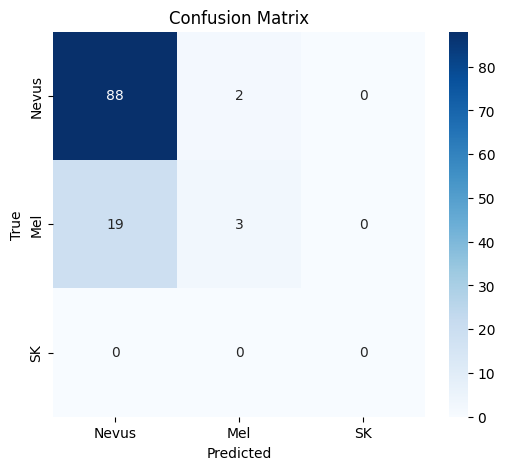

In [ ]:
# Load best model
model.load_state_dict(torch.load(best_path, map_location=device))

# Evaluate
val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader)
print("FINAL VAL ACC:", val_acc)

# Classification report (fixed)
print(classification_report(
    val_labels,
    val_preds,
    labels=[0,1,2],
    target_names=["Nevus","Melanoma","Seborrheic_Keratosis"],
    zero_division=0
))

# Confusion matrix
import seaborn as sns
cm = confusion_matrix(val_labels, val_preds, labels=[0,1,2])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Nevus","Mel","SK"],
            yticklabels=["Nevus","Mel","SK"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# run in shell cell if needed
!pip install -q grad-cam shap==0.41.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 27.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def generate_gradcam(model, img_tensor, feats_tensor, target_class=None):
    model.eval()

    # Grad-CAM works on last conv layer of ResNet34
    target_layer = model.backbone.layer4[-1]

    cam = GradCAM(model=model, target_layers=[target_layer], use_cuda=(device=="cuda"))

    # Prepare target class
    if target_class is None:
        with torch.no_grad():
            out = model(img_tensor, feats_tensor)
            target_class = out.argmax(dim=1).item()

    targets = [ClassifierOutputTarget(target_class)]

    grayscale_cam = cam(
        input_tensor=img_tensor,
        targets=targets,
        aug_smooth=True,
        eigen_smooth=True
    )[0]

    # Convert tensor → numpy RGB
    img_np = img_tensor[0].permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    return visualization


In [ ]:
class FusionGradCAMWrapper(nn.Module):
    def __init__(self, fusion_model, fixed_feats):
        super().__init__()
        self.fusion_model = fusion_model
        self.fixed_feats = fixed_feats  # tensor of features (1,7)

    def forward(self, x):
        # x = image tensor
        # feats = stored ABCD vector
        feats = self.fixed_feats.expand(x.size(0), -1)
        return self.fusion_model(x, feats)


In [ ]:
def generate_gradcam(fusion_model, img_tensor, feats_tensor, target_class=None):
    fusion_model.eval()

    # WRAP THE MODEL FOR GRAD-CAM
    wrapped = FusionGradCAMWrapper(fusion_model, feats_tensor)

    target_layer = fusion_model.backbone.layer4[-1]

    cam = GradCAM(
        model=wrapped,
        target_layers=[target_layer],
        use_cuda=(device=="cuda")
    )

    # determine predicted class if not provided
    if target_class is None:
        with torch.no_grad():
            out = fusion_model(img_tensor, feats_tensor)
            target_class = out.argmax(1).item()

    targets = [ClassifierOutputTarget(target_class)]

    grayscale_cam = cam(
        input_tensor=img_tensor,
        targets=targets,
        aug_smooth=True,
        eigen_smooth=True
    )[0]

    # Convert to RGB
    img_np = img_tensor[0].permute(1,2,0).detach().cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    heatmap = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    return heatmap


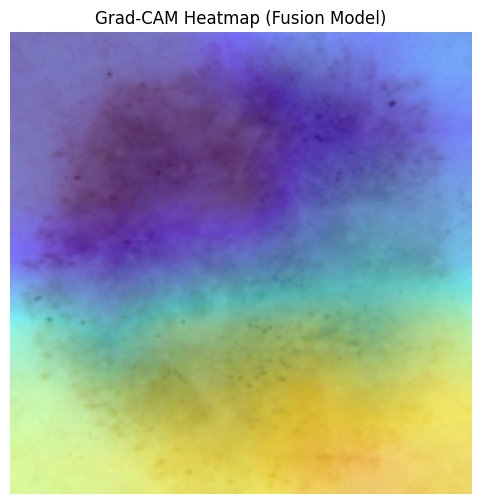

In [ ]:
img_t, feats_t, label = val_ds[0]
img_t   = img_t.unsqueeze(0).to(device)
feats_t = feats_t.unsqueeze(0).to(device)

heatmap = generate_gradcam(model, img_t, feats_t)

plt.figure(figsize=(6,6))
plt.imshow(heatmap)
plt.axis("off")
plt.title("Grad-CAM Heatmap (Fusion Model)")
plt.show()


Device: cpu

Paste an image URL (http...) or local path. Example Google image URL or '/content/test.jpg'
Image URL or path: /content/Screenshot 2025-11-19 234808.png


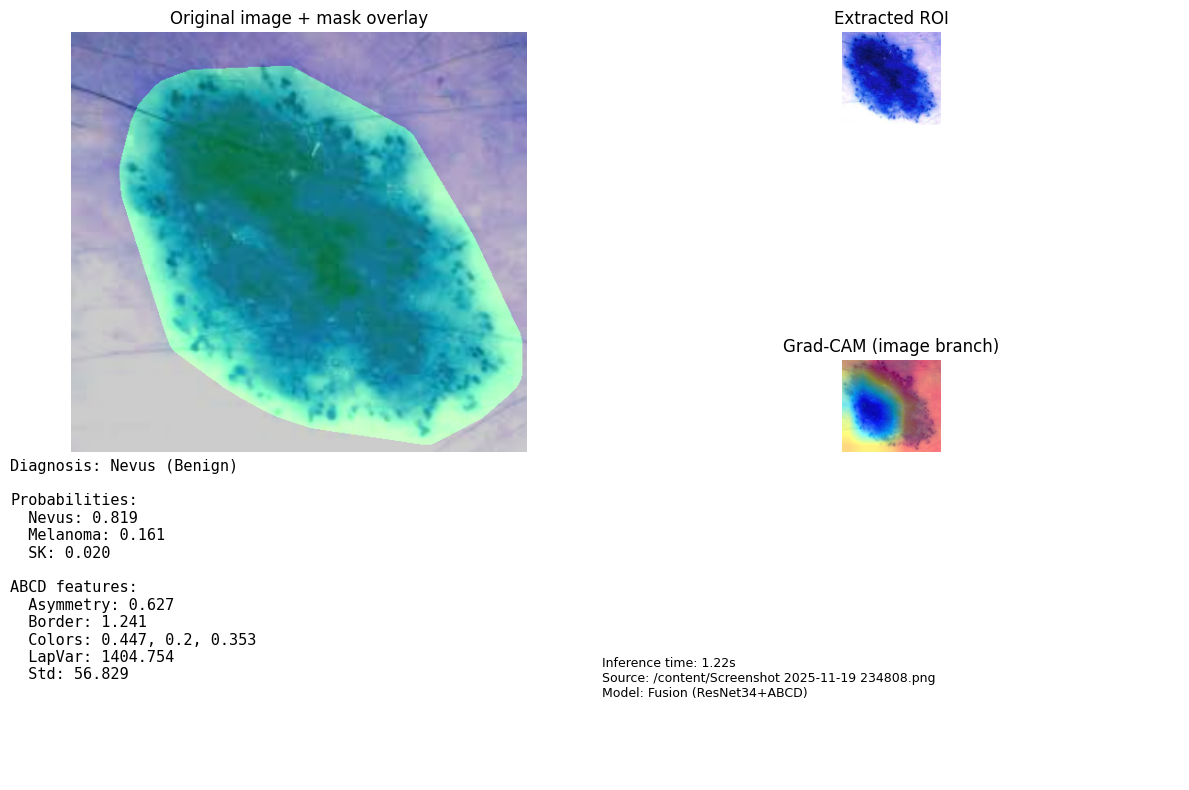

Saved report: /content/drive/MyDrive/ISIC_3B/demo_reports/dermassist_report_20251119_181924.png

DIAGNOSIS: Nevus (Benign)
Probs: [0.81941336 0.16074732 0.01983939]
ABCD: {'A': 0.627, 'B': 1.241, 'C': [0.447, 0.2, 0.353], 'Lap': 1404.754, 'Std': 56.829}


In [ ]:
# ===== SINGLE-CELL DEMO: Upload/URL -> Segmentation -> ABCD -> Fusion classifier -> Grad-CAM -> Report =====
import os, io, time, requests
from datetime import datetime
import numpy as np, pandas as pd
import cv2, matplotlib.pyplot as plt
from PIL import Image
import torch, torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ------------ EDIT THESE PATHS IF NEEDED ------------
UNET_CKPT   = "/content/drive/MyDrive/ISIC_3B/checkpoints/unet_best.pth"
FUSION_CKPT = "/content/drive/MyDrive/ISIC_3B/fusion_output/fusion_epoch1.pth"
OUT_DIR     = "/content/drive/MyDrive/ISIC_3B/demo_reports"
os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ----------------- Utility: load image from URL or local path -----------------
def load_image_any(path_or_url):
    if str(path_or_url).lower().startswith("http"):
        r = requests.get(path_or_url, timeout=15)
        r.raise_for_status()
        img = np.array(Image.open(io.BytesIO(r.content)).convert("RGB"))
    else:
        img = np.array(Image.open(path_or_url).convert("RGB"))
    return img  # H,W,3 RGB uint8

# ----------------- ABCD feature functions (robust) -----------------
from sklearn.cluster import KMeans
def asymmetry(mask):
    m = (mask>0).astype(np.uint8)
    h,w = m.shape
    if w%2!=0: m = m[:,:-1]; w-=1
    if h%2!=0: m = m[:-1,:]; h-=1
    mid_x, mid_y = w//2, h//2
    left = m[:, :mid_x]; right = m[:, mid_x:]; right_flip = np.fliplr(right)
    A_v = 1 - (np.sum(left & right_flip) / max(np.sum(m),1))
    top = m[:mid_y, :]; bot = m[mid_y:, :]; bot_flip = np.flipud(bot)
    A_h = 1 - (np.sum(top & bot_flip) / max(np.sum(m),1))
    return float(round((A_v + A_h)/2, 3))

def border_irregularity(mask):
    m = (mask>0).astype(np.uint8)
    cnts,_ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return 0.0
    c = max(cnts, key=cv2.contourArea)
    per = cv2.arcLength(c, True); area = cv2.contourArea(c)
    if area<=0: return 0.0
    compact = (per**2) / (4 * np.pi * area)
    return float(round(compact,3))

def color_variation(img_rgb, mask, k=3):
    # img_rgb: uint8 RGB, mask: 0/1
    pts = img_rgb[mask>0]
    if len(pts)==0: return [0.0]*k
    # convert to LAB for color clustering
    lab = cv2.cvtColor(pts.reshape(-1,1,3).astype(np.uint8), cv2.COLOR_RGB2LAB).reshape(-1,3)
    try:
        kmeans = KMeans(n_clusters=min(k, len(lab)), random_state=0).fit(lab)
    except Exception:
        counts = np.bincount(np.zeros(len(lab), dtype=int))
        props = (counts / counts.sum()).tolist()
        return [float(round(p,3)) for p in props] + [0.0]*(k-len(props))
    counts = np.bincount(kmeans.labels_)
    props = (counts / counts.sum()).tolist()
    props = props + [0.0]*(k-len(props))
    return [float(round(p,3)) for p in props[:k]]

def texture_score(img_rgb, mask):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    masked = gray.copy(); masked[mask==0]=0
    if masked.sum()==0: return 0.0, 0.0
    lap_var = float(cv2.Laplacian(masked, cv2.CV_64F).var())
    std = float(masked[mask>0].std()) if (mask>0).sum()>0 else 0.0
    return float(round(lap_var,3)), float(round(std,3))

# ----------------- Helper: largest component bbox & mask clean -----------------
def keep_largest(mask):
    m = (mask>0).astype(np.uint8)
    cnts,_ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
    c = max(cnts, key=cv2.contourArea)
    hull = cv2.convexHull(c)
    out = np.zeros_like(m); cv2.drawContours(out, [hull], -1, 255, -1)
    return out

# ----------------- Build U-Net architecture and load checkpoint -----------------
# We assume the U-Net used earlier was segmentation_models_pytorch.Unet with resnet34 encoder.
try:
    import segmentation_models_pytorch as smp
except Exception:
    smp = None

def build_unet(checkpoint_path):
    if smp is None:
        raise RuntimeError("Install segmentation_models_pytorch to run U-Net inference.")
    model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1, activation=None)
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"UNet checkpoint not found at {checkpoint_path}")
    sd = torch.load(checkpoint_path, map_location="cpu")
    model.load_state_dict(sd)
    model.to(device).eval()
    return model

# ----------------- Build Fusion model class (must match training definition) -----------------
class FusionNet(nn.Module):
    def __init__(self, feat_dim=7, num_classes=3, pretrained=True):
        super().__init__()
        self.backbone = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None)
        backbone_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.feat_net = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(backbone_dim + 32, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, img, feats):
        img_emb = self.backbone(img)
        feat_emb = self.feat_net(feats)
        x = torch.cat([img_emb, feat_emb], dim=1)
        return self.classifier(x)

def build_fusion(checkpoint_path):
    model = FusionNet(feat_dim=7, num_classes=3, pretrained=True)
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Fusion checkpoint not found at {checkpoint_path}")
    sd = torch.load(checkpoint_path, map_location="cpu")
    model.load_state_dict(sd)
    model.to(device).eval()
    return model

# ----------------- Grad-CAM wrapper that uses zero-features (image-only CAM) -----------------
class FusionImageWrapper(nn.Module):
    def __init__(self, fusion_model, feat_dim=7):
        super().__init__()
        self.fusion_model = fusion_model
        self.feat_dim = feat_dim
    def forward(self, x):
        # produce zeros for features so wrapper accepts single-input signature
        z = torch.zeros((x.size(0), self.feat_dim), device=x.device, dtype=torch.float32)
        return self.fusion_model(x, z)

# ----------------- transforms (U-Net & classifier) -----------------
def unet_preprocess(img, target_size=256):
    # img: RGB uint8
    im = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_AREA).astype(np.float32)/255.0
    mean = np.array([0.485,0.456,0.406]); std = np.array([0.229,0.224,0.225])
    im = (im - mean)/std
    im = np.transpose(im, (2,0,1))[None,:].astype(np.float32)
    return torch.from_numpy(im)

def classifier_preprocess(img, size=224):
    # img: RGB uint8 (ROI)
    tf = T.Compose([T.ToPILImage(), T.Resize((size,size)), T.ToTensor(),
                    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    return tf(img)

# ----------------- MAIN pipeline function -----------------
def dermassist_demo(input_path_or_url):
    start = time.time()
    img = load_image_any(input_path_or_url)
    H,W = img.shape[:2]

    # load models lazily first time
    global _UNET, _FUSION, _CAM_WRAPPER, _CAM_TARGET
    if "_UNET" not in globals():
        _UNET = build_unet(UNET_CKPT)
    if "_FUSION" not in globals():
        _FUSION = build_fusion(FUSION_CKPT)
        _CAM_WRAPPER = FusionImageWrapper(_FUSION, feat_dim=7).to(device)
        # choose target layer for GradCAM (resnet layer4 last block)
        _CAM_TARGET = _FUSION.backbone.layer4[-1]
    unet = _UNET; fusion = _FUSION; cam_wrapper = _CAM_WRAPPER; cam_target = _CAM_TARGET

    # 1) segmentation (U-Net)
    inp = unet_preprocess(img, target_size=256).to(device)
    with torch.no_grad():
        pred = unet(inp)[0,0].cpu().numpy()
    mask = (1.0/(1.0+np.exp(-pred)) > 0.5).astype(np.uint8) * 255
    mask = cv2.resize(mask, (W,H), interpolation=cv2.INTER_NEAREST)

    # 2) keep largest component and bbox
    large = keep_largest(mask)
    if large is None or large.sum()==0:
        # fallback: center crop square 224
        cx,cy = W//2, H//2; s = min(W,H)//2
        x,y,w,h = cx-s, cy-s, 2*s, 2*s
        x = max(0,x); y=max(0,y); w=min(W-x,w); h=min(H-y,h)
        roi = img[y:y+h, x:x+w]
        seg_mask = mask
    else:
        seg_mask = (large>0).astype(np.uint8)*255
        cnts,_ = cv2.findContours((seg_mask>0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        c = max(cnts, key=cv2.contourArea)
        x,y,w,h = cv2.boundingRect(c)
        roi = img[y:y+h, x:x+w]

    if roi.size==0:
        raise RuntimeError("ROI extraction failed; check image and mask.")

    # 3) compute ABCD on original scale mask cropped to ROI
    mask_roi = seg_mask[y:y+h, x:x+w]
    mask_roi_bin = (mask_roi>0).astype(np.uint8)
    A = asymmetry(mask_roi_bin)
    B = border_irregularity(mask_roi_bin)
    C1,C2,C3 = color_variation(roi, mask_roi_bin, k=3)
    Lap, STD = texture_score(roi, mask_roi_bin)

    # 4) classifier inference (fusion)
    img_t = classifier_preprocess(roi).unsqueeze(0).to(device)   # 1,3,224,224
    feats_np = np.array([A, B, C1, C2, C3, Lap, STD], dtype=np.float32)
    feats_t = torch.from_numpy(feats_np).unsqueeze(0).to(device)
    with torch.no_grad():
        out = fusion(img_t, feats_t)
        probs = torch.softmax(out, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))

    class_names = ["Nevus (Benign)","Melanoma","Seborrheic Keratosis"]
    diagnosis = class_names[pred_idx]

    # 5) Grad-CAM (image-only on wrapper model)
    cam = GradCAM(model=cam_wrapper, target_layers=[cam_target])
    grayscale_cam = cam(input_tensor=img_t, targets=None)
    heatmap = grayscale_cam[0]
    # resize heatmap to roi display size
    roi_display = roi.astype(np.float32) / 255.0
    heatmap_resized = cv2.resize(heatmap, (roi_display.shape[1], roi_display.shape[0]))
    overlay = show_cam_on_image(roi_display, heatmap_resized, use_rgb=True)

    # 6) build report figure
    fig = plt.figure(figsize=(12,8))
    ax1 = plt.subplot2grid((3,4),(0,0),rowspan=2,colspan=2)
    ax2 = plt.subplot2grid((3,4),(0,2),rowspan=1,colspan=2)
    ax3 = plt.subplot2grid((3,4),(1,2),rowspan=1,colspan=2)
    ax4 = plt.subplot2grid((3,4),(2,0),rowspan=1,colspan=2)
    ax5 = plt.subplot2grid((3,4),(2,2),rowspan=1,colspan=2)

    # show original image with mask overlay semi-transparent
    rgb = img.copy()
    mask_rgb = np.zeros_like(rgb); mask_rgb[:,:,1]=seg_mask  # green mask
    overlay_orig = cv2.addWeighted(rgb.astype(np.uint8), 0.8, mask_rgb.astype(np.uint8), 0.4, 0)
    ax1.imshow(overlay_orig[:,:,::-1])  # convert to matplotlib RGB
    ax1.set_title("Original image + mask overlay"); ax1.axis('off')

    # ROI and overlay
    ax2.imshow(roi[:,:,::-1]); ax2.set_title("Extracted ROI"); ax2.axis('off')
    ax3.imshow(overlay[:,:,::-1]); ax3.set_title("Grad-CAM (image branch)"); ax3.axis('off')

    # ABCD table text
    ax4.axis('off')
    text = (f"Diagnosis: {diagnosis}\n\n"
            f"Probabilities:\n"
            f"  Nevus: {probs[0]:.3f}\n"
            f"  Melanoma: {probs[1]:.3f}\n"
            f"  SK: {probs[2]:.3f}\n\n"
            f"ABCD features:\n"
            f"  Asymmetry: {A}\n"
            f"  Border: {B}\n"
            f"  Colors: {C1}, {C2}, {C3}\n"
            f"  LapVar: {Lap}\n  Std: {STD}\n")
    ax4.text(0,0.9, text, fontsize=11, family='monospace')

    # small metadata
    ax5.axis('off')
    ax5.text(0,0.9, f"Inference time: {time.time()-start:.2f}s\nSource: {input_path_or_url}\nModel: Fusion (ResNet34+ABCD)", fontsize=9)

    plt.tight_layout()

    # save report image
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_path = os.path.join(OUT_DIR, f"dermassist_report_{stamp}.png")
    fig.savefig(out_path, dpi=150)
    plt.show()

    print("Saved report:", out_path)
    # return structured result if needed
    return {
        "diagnosis": diagnosis,
        "probabilities": probs,
        "ABCD": {"A":A,"B":B,"C":[C1,C2,C3],"Lap":Lap,"Std":STD},
        "report_path": out_path
    }

# ----------------- Run interactive prompt: supply a URL or local path -----------------
print("\nPaste an image URL (http...) or local path. Example Google image URL or '/content/test.jpg'")
input_path_or_url = input("Image URL or path: ").strip()
if input_path_or_url:
    try:
        res = dermassist_demo(input_path_or_url)
        print("\nDIAGNOSIS:", res["diagnosis"])
        print("Probs:", res["probabilities"])
        print("ABCD:", res["ABCD"])
    except Exception as e:
        print("ERROR during pipeline:", str(e))
        raise
else:
    print("No input provided. Edit the cell to set an image path or paste a URL when prompted.")
